In [1]:
import sys
from pathlib import Path
from typing import Dict

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image, Markdown

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data.preprocess_pcos import preprocess_pcos
from src.models.evaluate_models import evaluate_models
from src.models.train_logreg import train_logistic_regression
from src.models.train_random_forest import (
    extract_tree_feature_importances,
    train_decision_tree,
    train_gradient_boosting,
    train_random_forest,
    train_xgboost_optional,
)
from src.utils.config import CONFIG
from src.utils.io import save_dataframe
from src.utils.plotting import save_feature_importances

In [2]:
def relpath(p: Path) -> str:
    try:
        return str(p.relative_to(CONFIG.root_dir))
    except Exception:
        return p.name


def get_feature_names(pipeline, x_train: pd.DataFrame) -> list:
    preprocessor = pipeline.named_steps.get("preprocessor")
    if preprocessor is None:
        return list(x_train.columns)
    if hasattr(preprocessor, "get_feature_names_out"):
        return list(preprocessor.get_feature_names_out())
    return list(x_train.columns)


def best_model_name(metrics: pd.DataFrame) -> str:
    if metrics["roc_auc"].notna().any():
        return metrics.sort_values("roc_auc", ascending=False).iloc[0]["model_name"]
    return metrics.sort_values("f1", ascending=False).iloc[0]["model_name"]

In [3]:
def update_metrics_table(metrics: pd.DataFrame) -> pd.DataFrame:
    metrics = metrics.copy()
    best_name = best_model_name(metrics)
    metrics["is_best"] = metrics["model_name"] == best_name

    table_path = CONFIG.tables_dir / "model_metrics.csv"
    if table_path.exists():
        existing = pd.read_csv(table_path)
        existing = existing[existing["dataset"] != "pcos"]
        combined = pd.concat([existing, metrics], ignore_index=True)
    else:
        combined = metrics.copy()

    save_dataframe(combined, table_path)
    print(f"Saved combined metrics table to {relpath(table_path)}")
    return combined

In [4]:
def save_tree_feature_importances(
    model_name: str,
    pipeline,
    x_train: pd.DataFrame,
    dataset_label: str,
):
    feature_names = get_feature_names(pipeline, x_train)
    importances = extract_tree_feature_importances(pipeline, feature_names)

    table = (
        pd.DataFrame(
            {"feature": list(importances.keys()), "importance": list(importances.values())}
        )
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    csv_path = CONFIG.tables_dir / f"{dataset_label}_feature_importances.csv"
    fig_path = CONFIG.figures_dir / f"{dataset_label}_{model_name}_feature_importance.png"

    save_dataframe(table, csv_path)
    save_feature_importances(
        features=table["feature"],
        importances=table["importance"],
        title=f"{dataset_label.upper()} {model_name} Feature Importances",
        output_path=fig_path,
    )

    return table, csv_path, fig_path

In [5]:
def save_shap_summary(pipeline, x_train: pd.DataFrame, dataset_label: str) -> None:
    try:
        import shap
    except ImportError:
        print("shap not installed; skipping SHAP summary.")
        return

    preprocessor = pipeline.named_steps.get("preprocessor")
    model = pipeline.named_steps.get("model")
    if preprocessor is None or model is None:
        return

    x_transformed = preprocessor.transform(x_train)
    feature_names = get_feature_names(pipeline, x_train)

    try:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(x_transformed)
        shap.summary_plot(
            shap_values,
            x_transformed,
            feature_names=feature_names,
            show=False,
        )
        output_path = CONFIG.figures_dir / f"{dataset_label}_shap_summary.png"
        output_path.parent.mkdir(parents=True, exist_ok=True)
        shap.plt.gcf().savefig(output_path, dpi=200, bbox_inches="tight")
        shap.plt.close()
    except Exception as e:
        print(f"SHAP summary skipped due to error: {e}")
        return

In [6]:
x_train, x_test, y_train, y_test = preprocess_pcos()

print("PCOS train shape:", x_train.shape)
print("PCOS test shape:", x_test.shape)
print("\nTarget distribution (train):")
display(y_train.value_counts(dropna=False).rename("count").to_frame())

PCOS train shape: (432, 41)
PCOS test shape: (109, 41)

Target distribution (train):


,count
PCOS (Y/N),
0,291
1,141


In [7]:
models: Dict[str, object] = {}

models["logreg"] = train_logistic_regression(
    x_train,
    y_train,
    dataset_name="pcos",
    model_out=CONFIG.models_dir / "pcos" / "logreg.joblib",
    random_state=CONFIG.random_state,
)
print("Saved model: models/pcos/logreg.joblib")

models["decision_tree"] = train_decision_tree(
    x_train,
    y_train,
    dataset_name="pcos",
    model_out=CONFIG.models_dir / "pcos" / "decision_tree.joblib",
    random_state=CONFIG.random_state,
)
print("Saved model: models/pcos/decision_tree.joblib")

models["random_forest"] = train_random_forest(
    x_train,
    y_train,
    dataset_name="pcos",
    model_out=CONFIG.models_dir / "pcos" / "random_forest.joblib",
    random_state=CONFIG.random_state,
)
print("Saved model: models/pcos/random_forest.joblib")

Saved model: models/pcos/logreg.joblib
Saved model: models/pcos/decision_tree.joblib
Saved model: models/pcos/random_forest.joblib


In [8]:
try:
    models["xgboost"] = train_xgboost_optional(
        x_train,
        y_train,
        dataset_name="pcos",
        model_out=CONFIG.models_dir / "pcos" / "xgboost.joblib",
        random_state=CONFIG.random_state,
    )
    print("Saved model: models/pcos/xgboost.joblib")
except Exception as e:
    print(f"XGBoost unavailable, training Gradient Boosting instead: {e}")
    models["gradient_boosting"] = train_gradient_boosting(
        x_train,
        y_train,
        dataset_name="pcos",
        model_out=CONFIG.models_dir / "pcos" / "gradient_boosting.joblib",
        random_state=CONFIG.random_state,
    )
    print("Saved model: models/pcos/gradient_boosting.joblib")

Saved model: models/pcos/xgboost.joblib


In [9]:
pcos_metrics = evaluate_models(
    models=models,
    x_test=x_test,
    y_test=y_test,
    dataset_name="pcos",
    figures_dir=CONFIG.figures_dir,
    tables_dir=CONFIG.tables_dir,
)

display(Markdown("### PCOS model metrics"))
display(pcos_metrics.sort_values("roc_auc", ascending=False).reset_index(drop=True))

combined_metrics = update_metrics_table(pcos_metrics)

### PCOS model metrics

,dataset,model_name,accuracy,precision,recall,f1,roc_auc
0,pcos,logreg,0.889908,0.800000,0.888889,0.842105,0.951294
1,pcos,xgboost,0.935780,0.967742,0.833333,0.895522,0.950913
2,pcos,random_forest,0.926606,0.966667,0.805556,0.878788,0.933029
3,pcos,decision_tree,0.889908,0.852941,0.805556,0.828571,0.868531


Saved combined metrics table to reports/tables/model_metrics.csv


### Saved evaluation plots

reports/figures/pcos_roc_curves.png


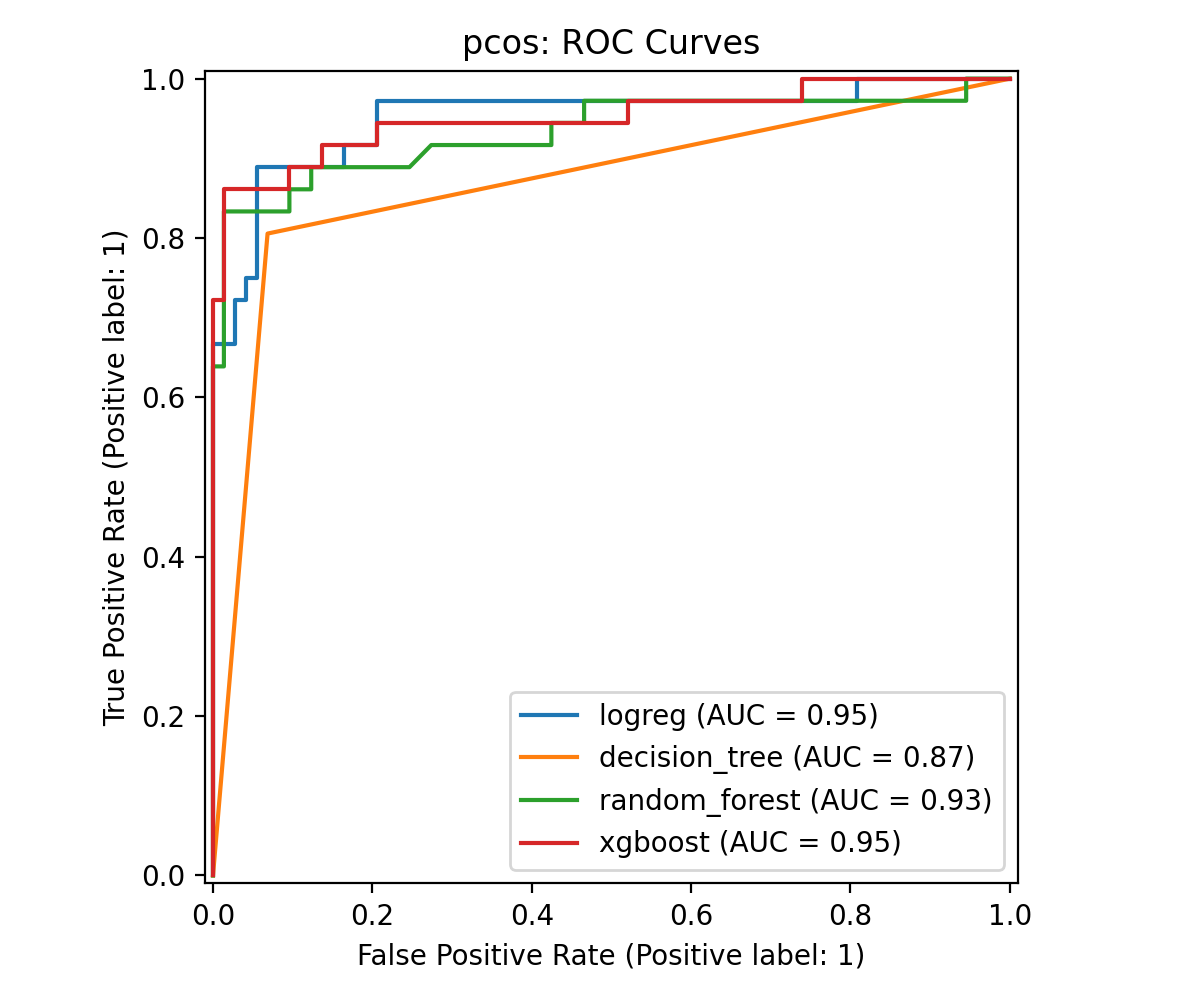

reports/figures/pcos_logreg_confusion_matrix.png


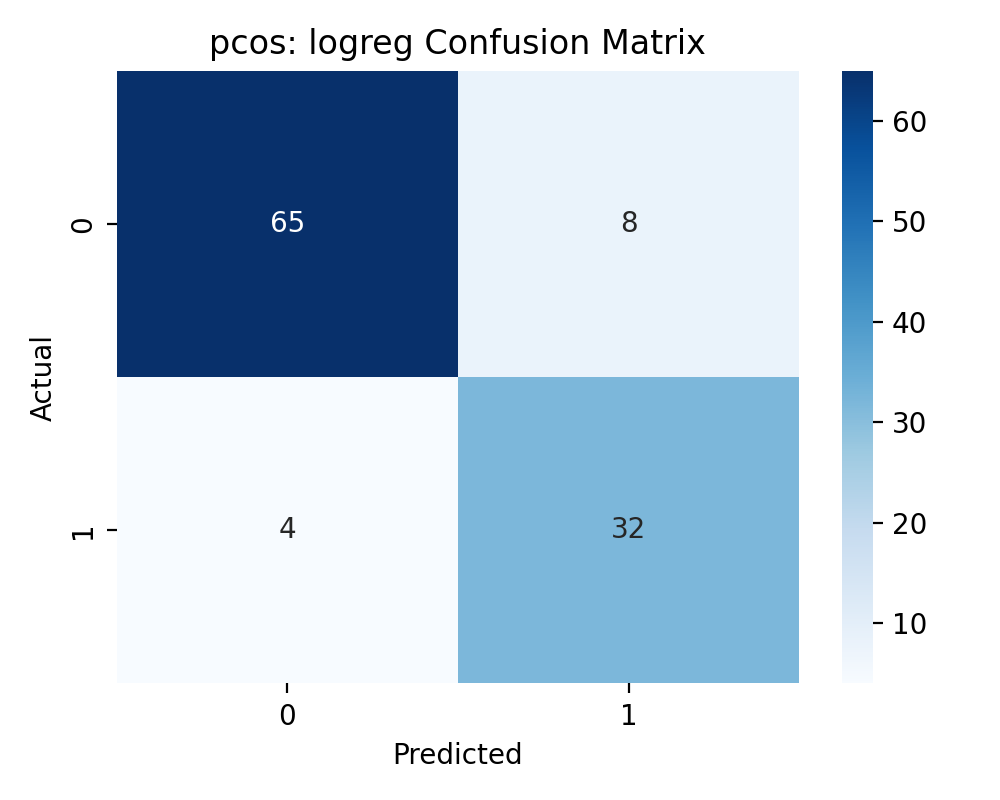

reports/figures/pcos_logreg_roc_curve.png


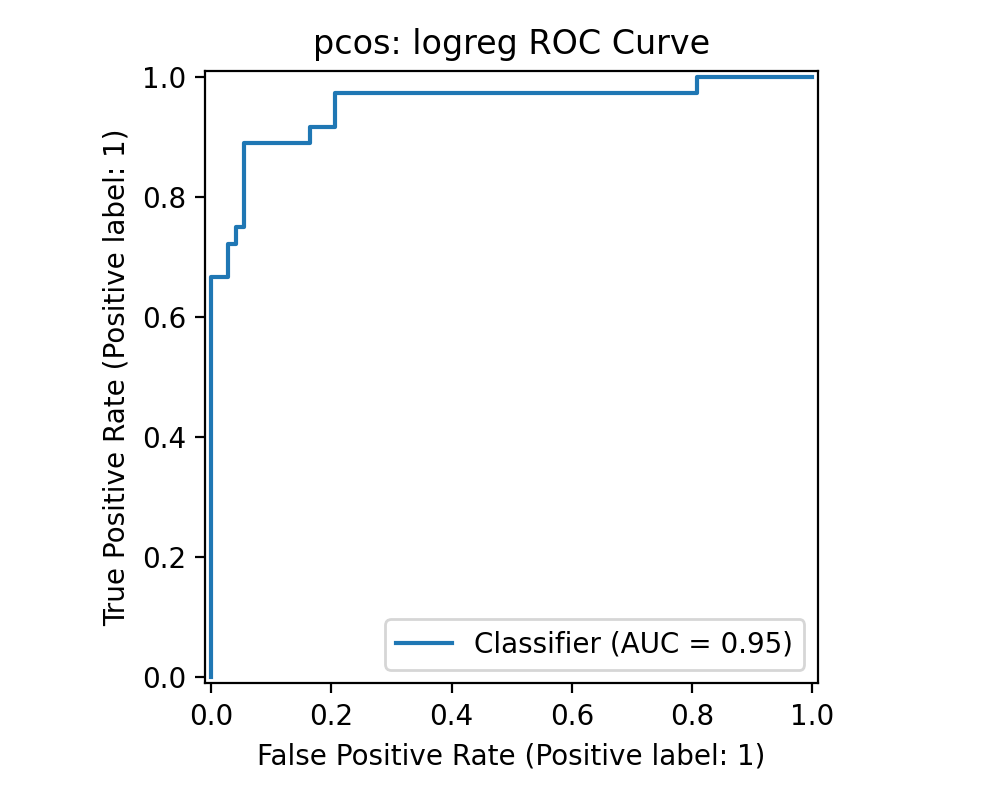

reports/figures/pcos_decision_tree_confusion_matrix.png


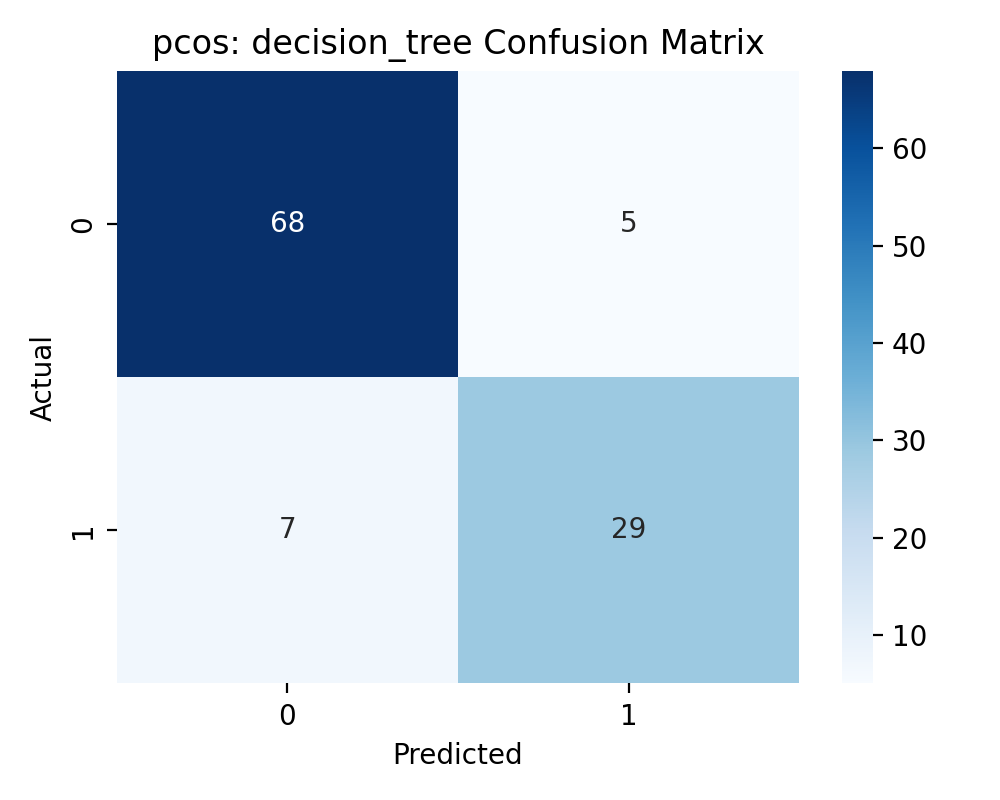

reports/figures/pcos_decision_tree_roc_curve.png


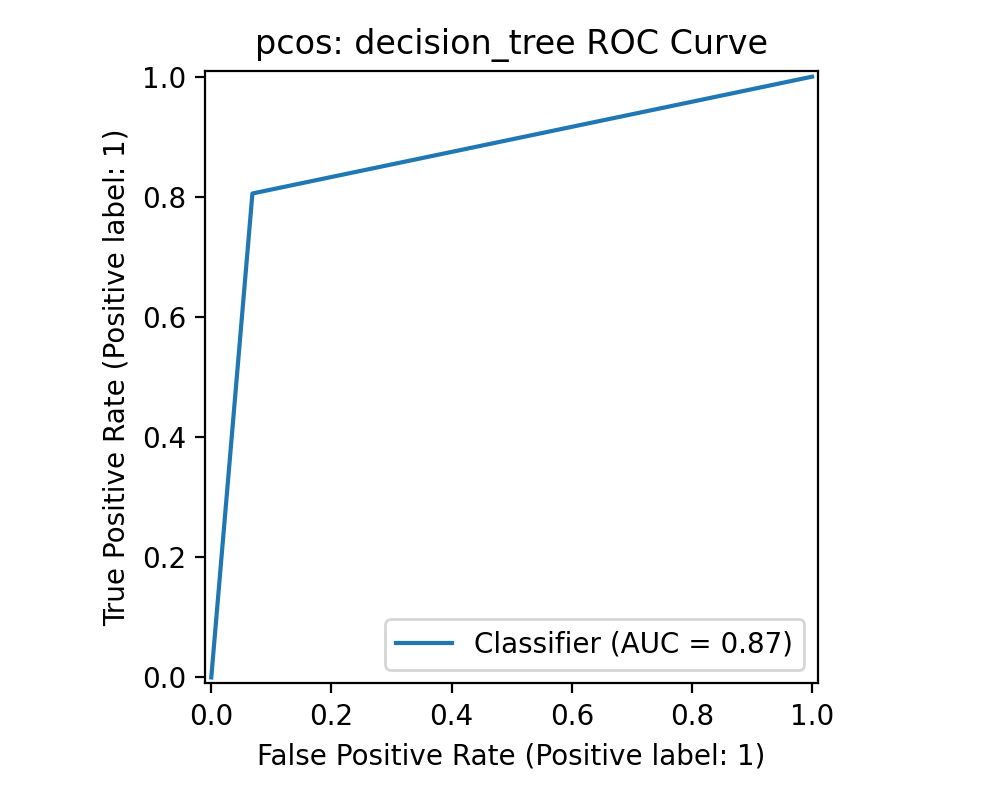

reports/figures/pcos_random_forest_confusion_matrix.png


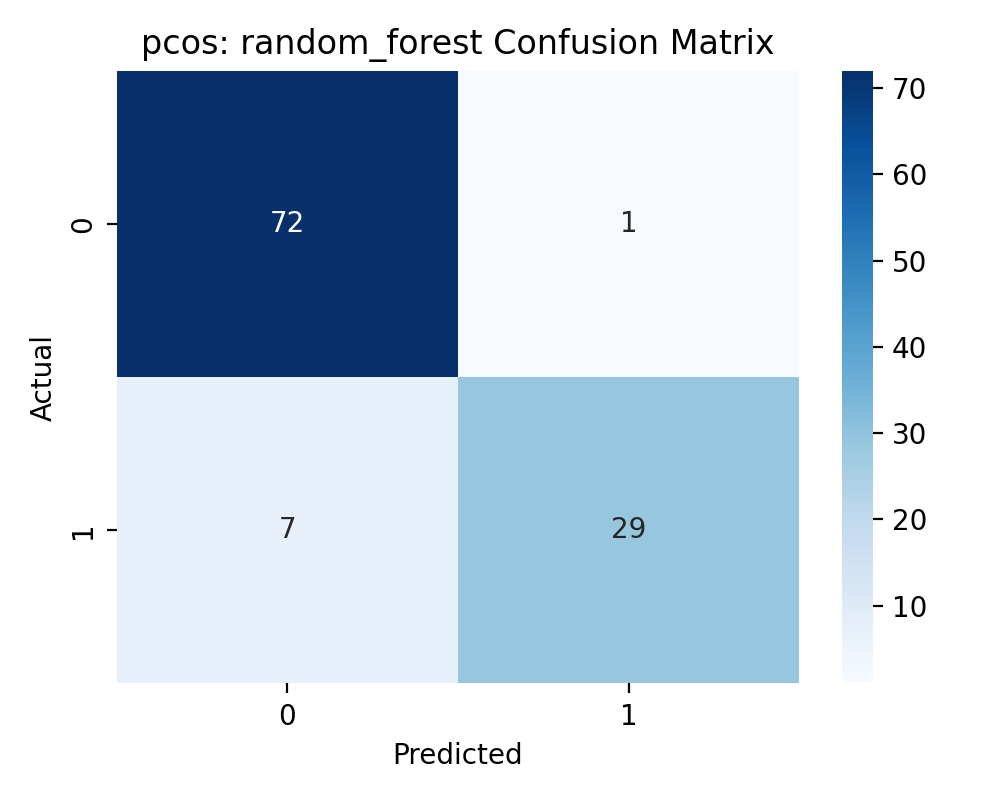

reports/figures/pcos_random_forest_roc_curve.png


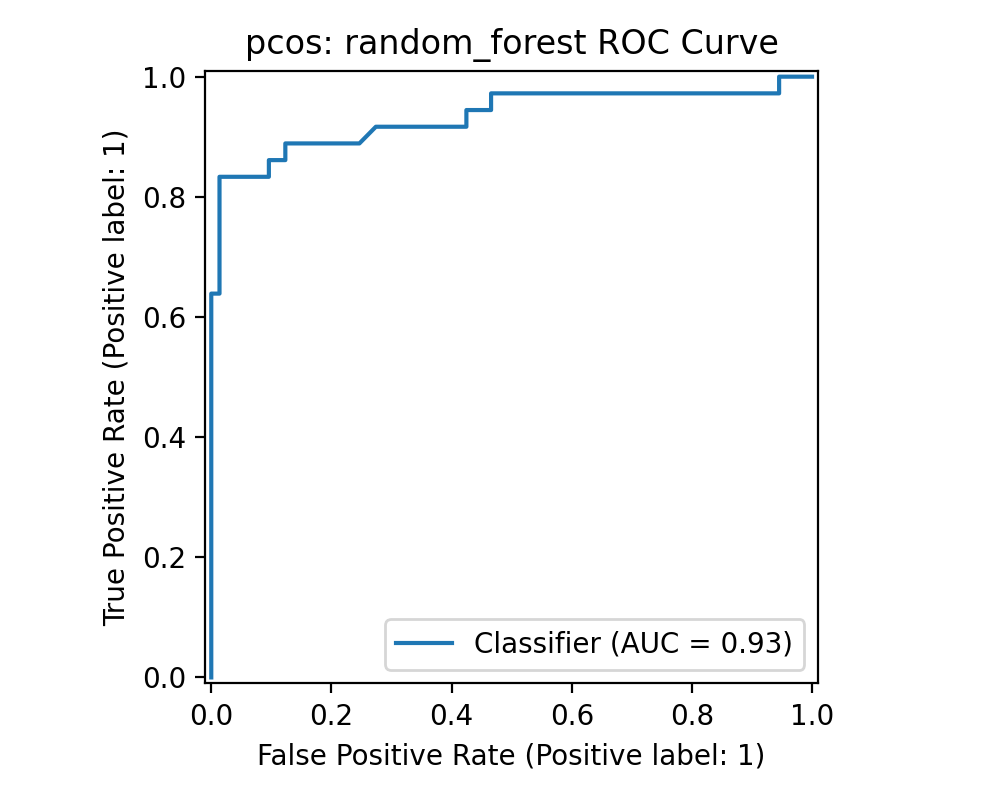

reports/figures/pcos_xgboost_confusion_matrix.png


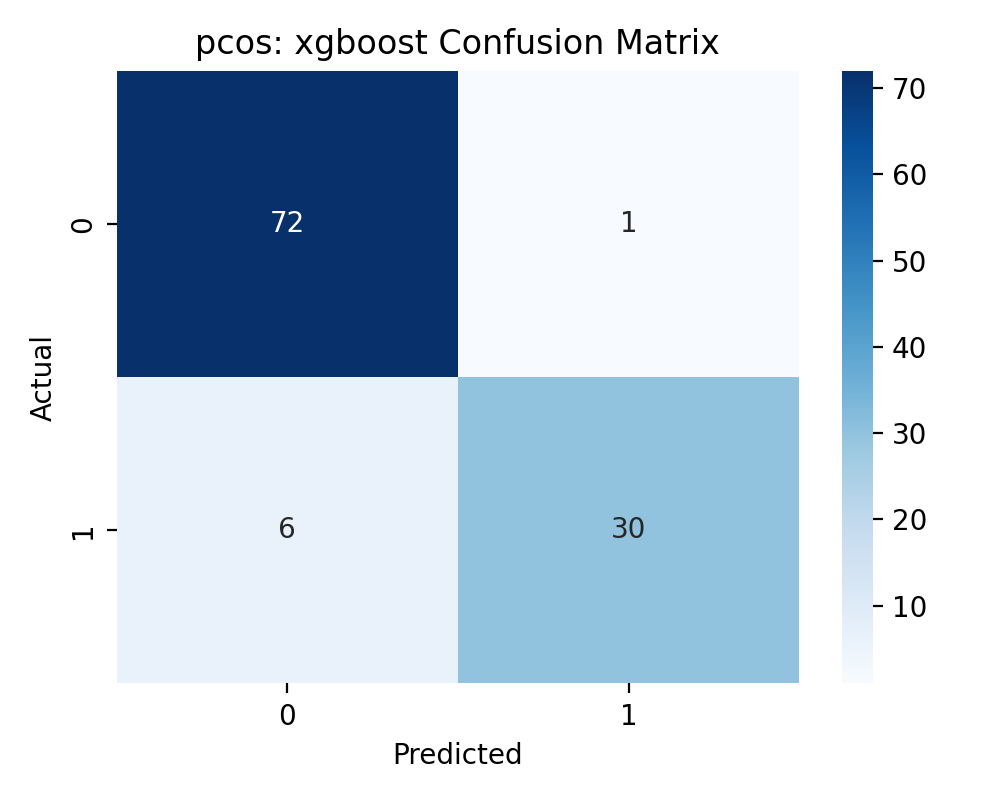

reports/figures/pcos_xgboost_roc_curve.png


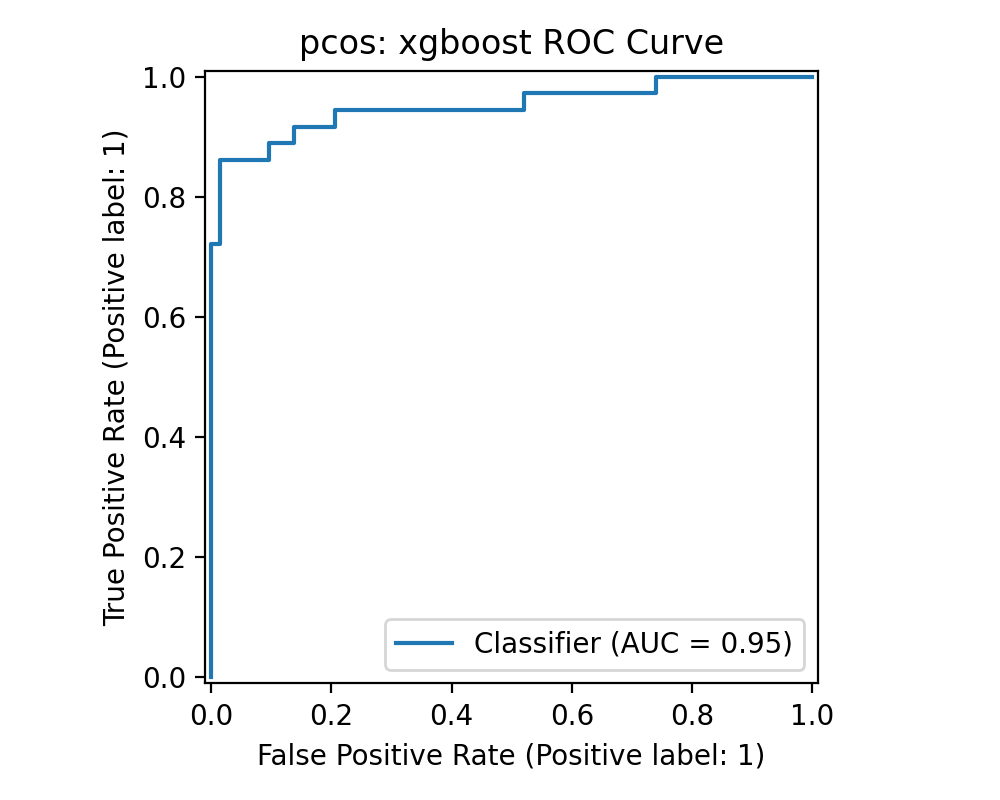

In [10]:
display(Markdown("### Saved evaluation plots"))

plot_files = [
    CONFIG.figures_dir / "pcos_roc_curves.png",
]

for model_name in models.keys():
    plot_files.append(CONFIG.figures_dir / f"pcos_{model_name}_confusion_matrix.png")
    plot_files.append(CONFIG.figures_dir / f"pcos_{model_name}_roc_curve.png")

for plot_path in plot_files:
    if plot_path.exists():
        print(relpath(plot_path))
        display(Image(filename=str(plot_path)))

Best tree-based model: xgboost


### Top PCOS feature importances

,feature,importance
0,num__Follicle No. (R),0.132302
1,num__Follicle No. (L),0.069366
2,num__hair growth(Y/N),0.066312
3,num__Weight gain(Y/N),0.045520
4,num__Skin darkening (Y/N),0.044354
5,num__Reg.Exercise(Y/N),0.043021
6,num__Pregnant(Y/N),0.039208
7,num__Cycle(R/I),0.038193
8,num__Fast food (Y/N),0.035500
9,num__Avg. F size (R) (mm),0.025937


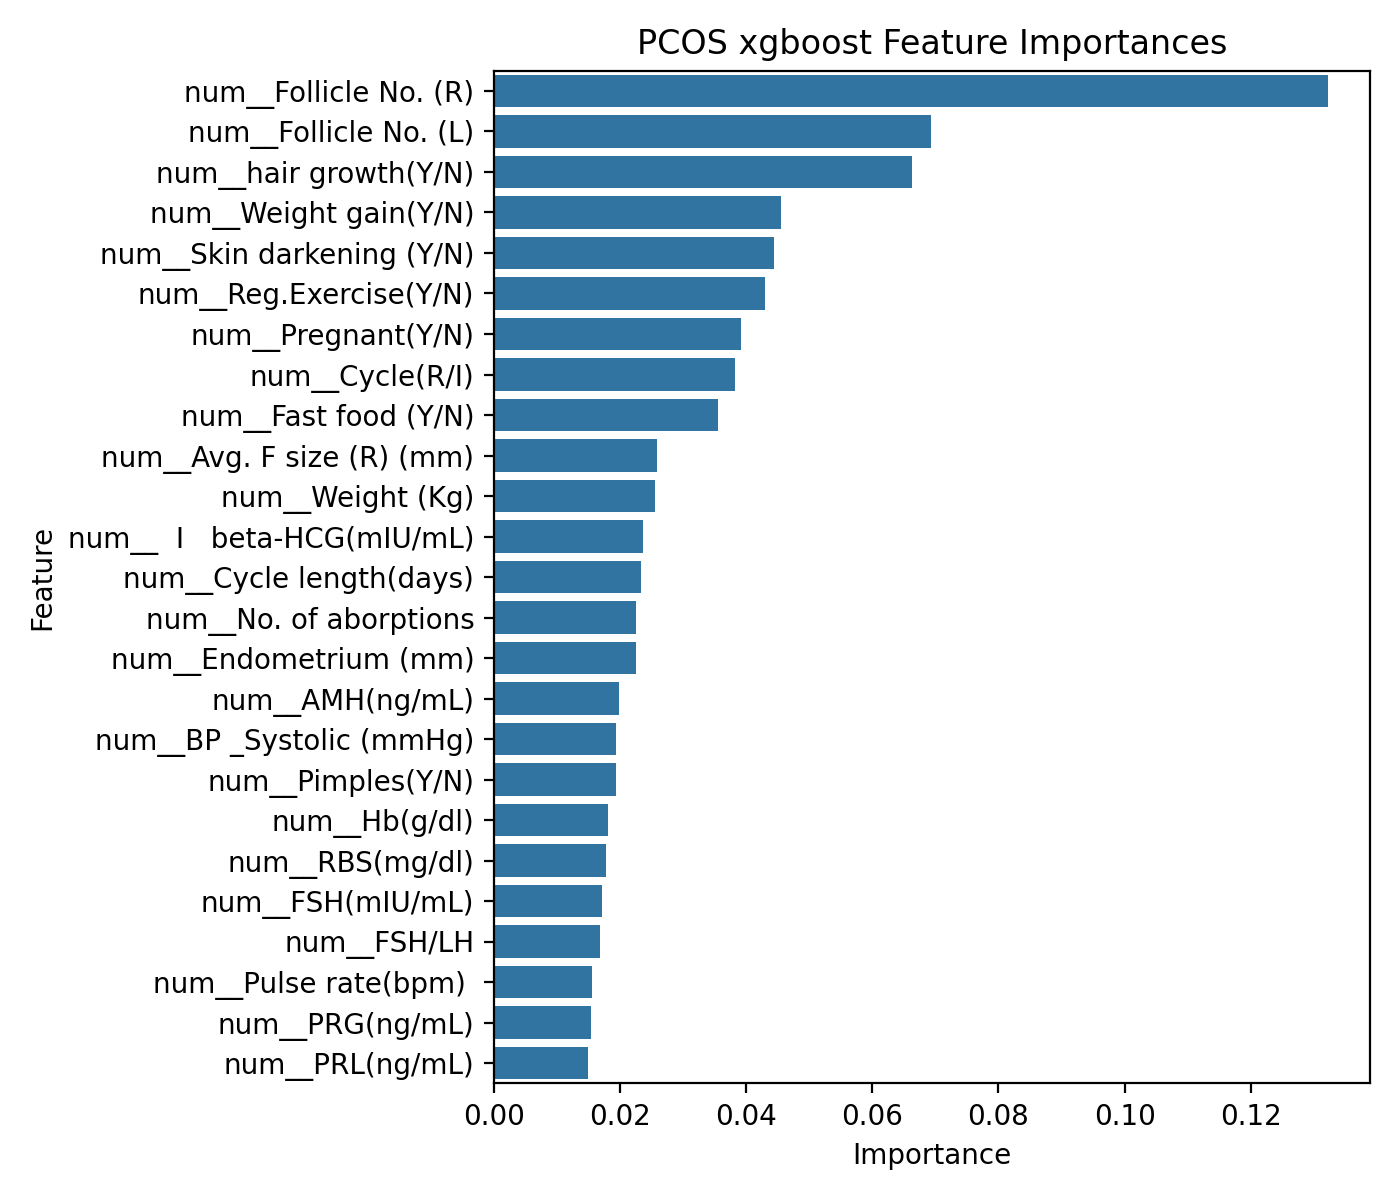

SHAP summary skipped due to error: module 'shap' has no attribute 'plt'


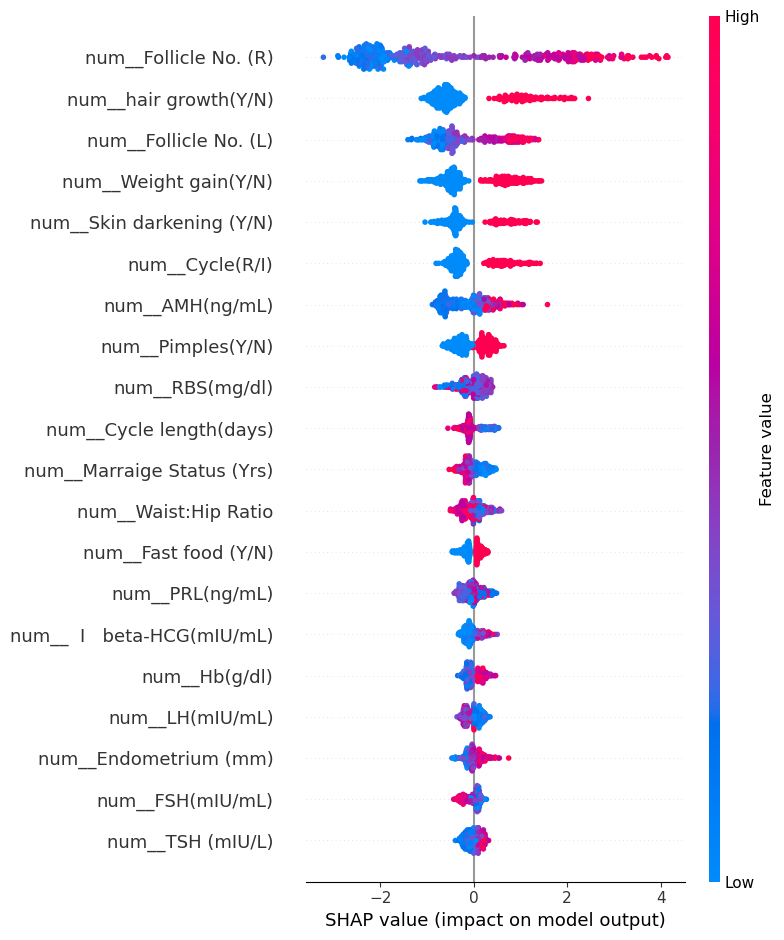

In [11]:
tree_candidates = {k: v for k, v in models.items() if k != "logreg"}

if tree_candidates:
    tree_metrics = pcos_metrics[pcos_metrics["model_name"].isin(tree_candidates.keys())]
    best_tree_name = best_model_name(tree_metrics)
    best_tree = tree_candidates[best_tree_name]

    print("Best tree-based model:", best_tree_name)

    fi_table, fi_csv_path, fi_fig_path = save_tree_feature_importances(
        best_tree_name, best_tree, x_train, "pcos"
    )

    display(Markdown("### Top PCOS feature importances"))
    display(fi_table.head(20))
    display(Image(filename=str(fi_fig_path)))

    shap_path = save_shap_summary(best_tree, x_train, "pcos")
    if shap_path is not None and Path(shap_path).exists():
        display(Markdown("### SHAP summary"))
        display(Image(filename=str(shap_path)))
else:
    print("No tree-based models available for feature importance.")